In [1]:
import sys
import os
import warnings

sys.path.append(os.path.abspath("../scripts"))

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score, 
    precision_score, recall_score
)

from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

from data_loader import get_openml_data
from data_preprocessing import create_preprocessing_pipeline, preprocess_for_nn
from boosting_models import run_lr_tuning, run_catboost_tuning, run_lgbm_tuning
from deep_model import TabularDataset, TABMLP, train, evaluate

warnings.filterwarnings("ignore")

## Датасет [California](https://www.openml.org/search?type=data&status=active&id=44090)

In [2]:
dataset_id = 44090
X_train, X_valid, X_test, y_train, y_valid, y_test, categorical_indicator, attribute_names = get_openml_data(dataset_id)

In [3]:
column_transformer, categorical_features, numerical_features = create_preprocessing_pipeline(attribute_names, categorical_indicator)

In [4]:
model_lr = run_lr_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_lr = model_lr.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, model_lr.predict_proba(X_test)[:, 1]))
print("F1 = %.4f" % f1_score(y_test, y_pred_lr))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_lr))
print("Precision = %.4f" % precision_score(y_test, y_pred_lr))
print("Recall = %.4f" % recall_score(y_test, y_pred_lr))

[I 2025-04-14 19:09:44,557] A new study created in memory with name: logistic_regression_optimization
[I 2025-04-14 19:09:44,635] Trial 0 finished with value: 0.9095926476774233 and parameters: {'penalty': 'l2', 'C': 0.1}. Best is trial 0 with value: 0.9095926476774233.
[I 2025-04-14 19:09:44,655] Trial 1 finished with value: 0.8382318144943213 and parameters: {'penalty': 'l2', 'C': 1e-05}. Best is trial 0 with value: 0.9095926476774233.
[I 2025-04-14 19:09:44,697] Trial 2 finished with value: 0.9095926476774233 and parameters: {'penalty': 'l2', 'C': 0.1}. Best is trial 0 with value: 0.9095926476774233.
[I 2025-04-14 19:09:44,773] Trial 3 finished with value: 0.9135765954570038 and parameters: {'penalty': 'l1', 'C': 1}. Best is trial 3 with value: 0.9135765954570038.
[I 2025-04-14 19:09:44,799] Trial 4 finished with value: 0.8657401147767563 and parameters: {'penalty': 'l2', 'C': 0.001}. Best is trial 3 with value: 0.9135765954570038.
[I 2025-04-14 19:09:44,835] Trial 5 finished with v

ROC-AUC = 0.9105
F1 = 0.8285
Accuracy = 0.8274
Precision = 0.8230
Recall = 0.8341


In [5]:
model_cb = run_catboost_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_cb = model_cb.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, model_cb.predict_proba(X_test)[:, 1]))
print("F1 = %.4f" % f1_score(y_test, y_pred_cb))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_cb))
print("Precision = %.4f" % precision_score(y_test, y_pred_cb))
print("Recall = %.4f" % recall_score(y_test, y_pred_cb))

[I 2025-04-14 19:09:45,913] A new study created in memory with name: catboost_optimization
[I 2025-04-14 19:09:48,622] Trial 0 finished with value: 0.9692795655309174 and parameters: {'depth': 4, 'learning_rate': 0.1, 'l2_leaf_reg': 0.1}. Best is trial 0 with value: 0.9692795655309174.
[I 2025-04-14 19:09:58,027] Trial 1 finished with value: 0.9444200318490475 and parameters: {'depth': 10, 'learning_rate': 0.001, 'l2_leaf_reg': 3.0}. Best is trial 0 with value: 0.9692795655309174.
[I 2025-04-14 19:10:00,717] Trial 2 finished with value: 0.9656373940868938 and parameters: {'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 6.0}. Best is trial 0 with value: 0.9692795655309174.
[I 2025-04-14 19:10:07,066] Trial 3 finished with value: 0.9637604410792621 and parameters: {'depth': 10, 'learning_rate': 0.3, 'l2_leaf_reg': 0.1}. Best is trial 0 with value: 0.9692795655309174.
[I 2025-04-14 19:10:11,750] Trial 4 finished with value: 0.9700870590709694 and parameters: {'depth': 8, 'learning_rate'

ROC-AUC = 0.9673
F1 = 0.9018
Accuracy = 0.9021
Precision = 0.9036
Recall = 0.9001


In [6]:
model_lgbm = run_lgbm_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_lgbm = model_lgbm.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, model_lgbm.predict_proba(X_test)[:, 1]))
print("F1 = %.4f" % f1_score(y_test, y_pred_lgbm))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_lgbm))
print("Precision = %.4f" % precision_score(y_test, y_pred_lgbm))
print("Recall = %.4f" % recall_score(y_test, y_pred_lgbm))

[I 2025-04-14 19:11:08,295] A new study created in memory with name: lightgbm_optimization
[I 2025-04-14 19:11:08,751] Trial 0 finished with value: 0.9676542500450693 and parameters: {'num_leaves': 4, 'reg_alpha': 1e-06, 'reg_lambda': 1.0, 'learning_rate': 0.3}. Best is trial 0 with value: 0.9676542500450693.
[I 2025-04-14 19:11:09,717] Trial 1 finished with value: 0.9692335571780542 and parameters: {'num_leaves': 16, 'reg_alpha': 0.1, 'reg_lambda': 0.001, 'learning_rate': 0.3}. Best is trial 1 with value: 0.9692335571780542.
[I 2025-04-14 19:11:10,213] Trial 2 finished with value: 0.9689283997355927 and parameters: {'num_leaves': 1024, 'reg_alpha': 10.0, 'reg_lambda': 1e-08, 'learning_rate': 0.3}. Best is trial 1 with value: 0.9692335571780542.
[I 2025-04-14 19:11:41,423] Trial 3 finished with value: 0.970428835406526 and parameters: {'num_leaves': 2048, 'reg_alpha': 1e-05, 'reg_lambda': 1e-05, 'learning_rate': 0.03}. Best is trial 3 with value: 0.970428835406526.
[I 2025-04-14 19:11:

ROC-AUC = 0.9664
F1 = 0.9049
Accuracy = 0.9050
Precision = 0.9057
Recall = 0.9040


In [7]:
X_train, X_valid, X_test = preprocess_for_nn(X_train, X_valid, X_test, categorical_features, numerical_features)

In [8]:
trainset = TabularDataset(X_train, y_train, categorical_features)
valset = TabularDataset(X_valid, y_valid, categorical_features)
testset  = TabularDataset(X_test, y_test, categorical_features)

batch_size = 256
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(valset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(testset, batch_size=batch_size, shuffle=False)

In [9]:
cat_dims = [int(X_train[col].nunique()) for col in categorical_features]
emb_dims = [(x, min(50, (x + 1) // 2)) for x in cat_dims]

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


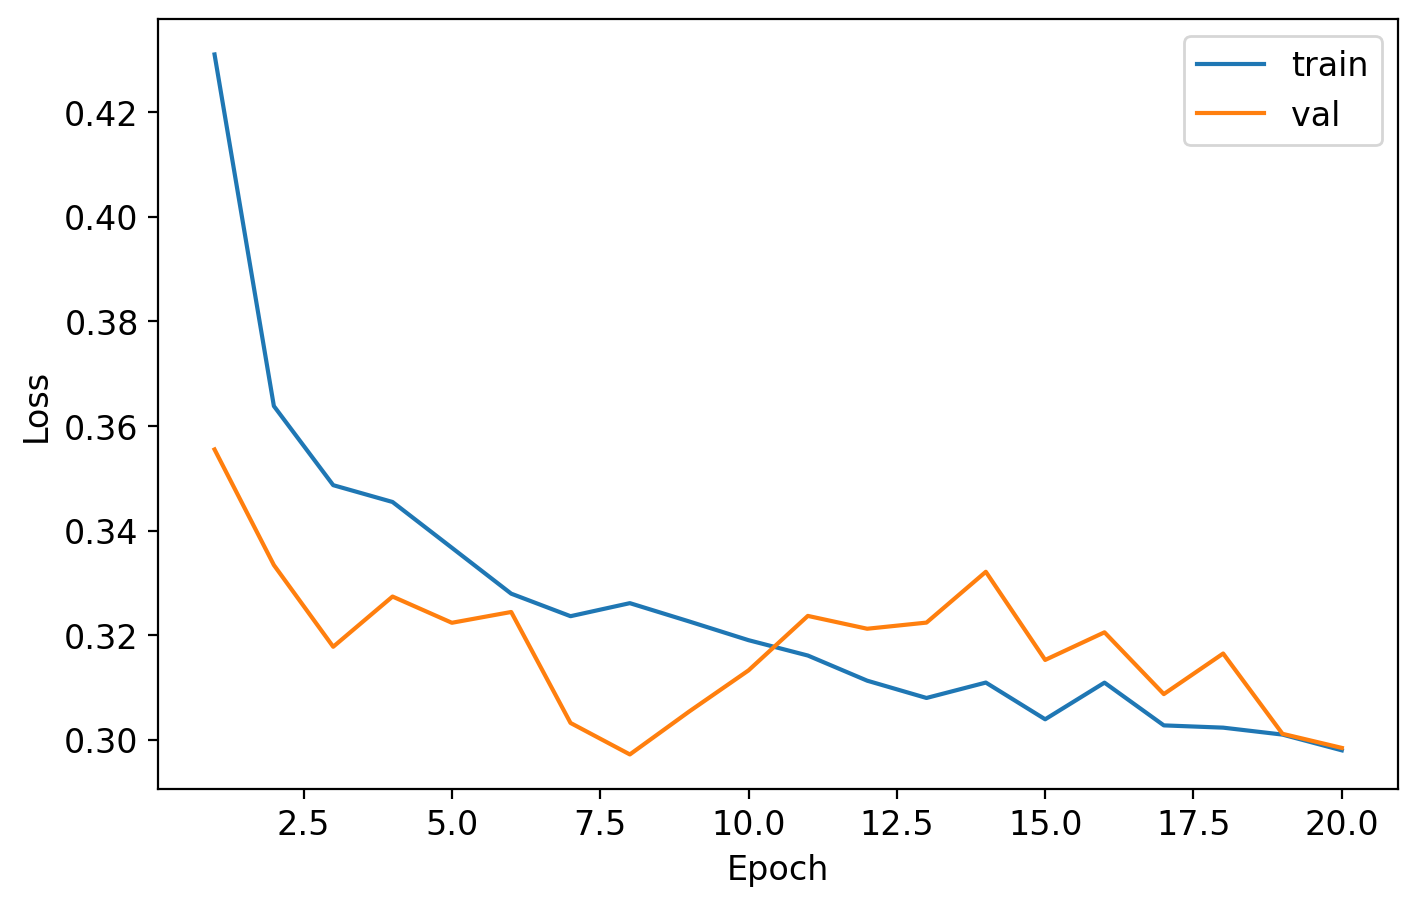

Epoch 20: train loss = 0.2980; valid loss = 0.2985


In [53]:
net = TABMLP(len(numerical_features), emb_dims).to(device)
optimizer = optim.Adam(net.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

train(net, optimizer, 20, train_loader, val_loader, criterion, device)

In [54]:
y_true, y_prob, y_pred = evaluate(net, test_loader, device)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, y_prob))
print("F1 = %.4f" % f1_score(y_test, y_pred))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred))
print("Precision = %.4f" % precision_score(y_test, y_pred))
print("Recall = %.4f" % recall_score(y_test, y_pred))

ROC-AUC = 0.9288
F1 = 0.8475
Accuracy = 0.8483
Precision = 0.8513
Recall = 0.8438
